# Electromotive Force (EMF) Plots

## Data Import

In [28]:
# Read EMF.csv

import pandas as pd
import os.path as path
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.axes import Axes
from matplotlib.ticker import FuncFormatter

import numpy as np

import darkdetect

if darkdetect.isDark():
    plt.style.use("dark_background")

plt.rcParams.update({
	'figure.dpi': 300,
	'figure.figsize': (8, 5),
})

%config InlineBackend.figure_formats = ['svg']

from cycler import cycler

default_cycler = plt.rcParams['axes.prop_cycle']
colors = default_cycler.by_key()['color']
line_styles = ['-', '--', '-.', ':']
combined_cycler = cycler(linestyle=line_styles) * cycler(color=colors)

plt.rcParams['axes.prop_cycle'] = combined_cycler

In [29]:
indexes_Stage = {
    "S01": {
        "Temperature": 0,
        "Duration": 24,
    },
    "S02": {
        "Temperature": 0,
        "Duration": 72,
    },
    "S03": {
        "Temperature": -10,
        "Duration": 24,
    },
    "S04": {
        "Temperature": -10,
        "Duration": 72,
    },
    "S05": {
        "Temperature": -20,
        "Duration": 24,
    },
    "S06": {
        "Temperature": -20,
        "Duration": 72,
    },
    "S07": {
        "Temperature": -30,
        "Duration": 24,
    },
    "S08": {
        "Temperature": -30,
        "Duration": 72,
    },
    "S09": {
        "Temperature": -40,
        "Duration": 24,
    },
    "S10": {
        "Temperature": -40,
        "Duration": 72,
    },
}

In [30]:
EMF_DATA_DIR = "../Data/Hand Notes"

emf_df = pd.read_csv(
    path.join(EMF_DATA_DIR, "EMF.csv"),
    delimiter=";",
    index_col=0,
)
emf_df.index = emf_df.index.str.split(
    " ",
    expand=True,
)

In [31]:
# Filter by the second level of the index
emf_vd_df = emf_df.xs("VD", level=1, axis=0)
emf_lt_df = emf_df.xs("LT", level=1, axis=0)

In [32]:
vd_plot = emf_vd_df.plot(
    title="EMF Varied Discharge",
    marker="o",
)
vd_plot.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f} V"))
# Show all ticks
vd_plot.set_xticks(
    range(len(emf_vd_df.index)),
    emf_vd_df.index,
)

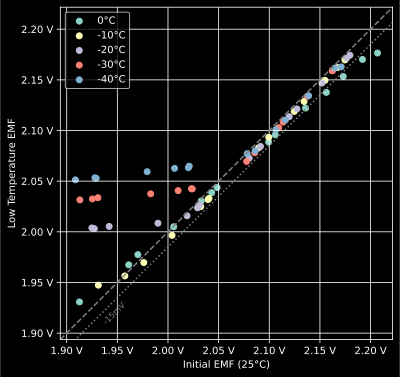

In [50]:
# For each LT stage, plot the corresponding VD EMF for the same stage against the LT EMF
def plot_emf_change(emf_vd_df, emf_lt_df) -> Figure:

    fig, ax = plt.subplots(
        figsize=(6, 6),
    )
    for stage in emf_lt_df.index.get_level_values(0).unique():
        lt_emf = emf_lt_df.loc[stage]
        vd_emf = emf_vd_df.loc[stage]
        ax.scatter(
            vd_emf / 6,
            lt_emf / 6,
            label=f"{indexes_Stage[stage]['Temperature']}°C",
        )

    ax.set_xlabel("Initial EMF (25°C)")
    ax.set_ylabel("Low Temperature EMF")
    ax.legend()
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f} V"))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f} V"))
    ax.set_aspect("equal", adjustable="box")
    ax.grid()

    # Set matching x and y ticks
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    min_tick = min(xlim[0], ylim[0])
    max_tick = max(xlim[1], ylim[1])
    ticks = plt.MaxNLocator(nbins=8).tick_values(min_tick, max_tick)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xlim(min_tick, max_tick)
    ax.set_ylim(min_tick, max_tick)

    # Plot y=x reference line
    ax.plot(
        [min_tick, max_tick],
        [min_tick, max_tick],
        linestyle="--",
        color="gray",
    )

    # Plot y = x - TC line
    TC = 0.015  # Volts per cell
    ax.plot(
        [min_tick, max_tick],
        [tick - TC for tick in [min_tick, max_tick]],
        linestyle=":",
        color="grey",
    )
    # Label the -15 mV line
    label_x = min_tick + 0.2 * (max_tick - min_tick)
    label_y = label_x - 3.5 * TC
    ax.text(
        label_x,
        label_y,
        f"{-TC*1000:.0f}mV",
        color="grey",
        fontsize="small",
        rotation=45,
        va="bottom",
        ha="right",
    )

    return fig


emf_change_plot = plot_emf_change(emf_vd_df, emf_lt_df)
emf_change_plot

## Frozen Instances

In [19]:
# Filter pairs of EMF values where the LT EMF is greater than the VD EMF
# Collect rows in a list (avoid DataFrame.append inside a loop and avoid shadowing global `battery`)

rows = []

for stage in emf_lt_df.index.get_level_values(0).unique():
    lt_emf = emf_lt_df.loc[stage]
    vd_emf = emf_vd_df.loc[stage]

    for batt in lt_emf.index:
        lt_value = float(lt_emf[batt])
        vd_value = float(vd_emf[batt])

        if lt_value > vd_value:
            rows.append(
                {
                    "VD_EMF": vd_value,
                    "LT_EMF": lt_value,
                    "Stage": stage,
                    "Temperature": indexes_Stage[stage]["Temperature"],
                }
            )

frozen_emf_df = pd.DataFrame(rows, columns=["VD_EMF", "LT_EMF", "Stage", "Temperature"])

In [20]:
## Filter instances of the 0°C and -10°C stages of <2.0V (due to expected positive thermal coefficient)

frozen_emf_df = frozen_emf_df[
    ~(
        ((frozen_emf_df["Temperature"] == 0) | (frozen_emf_df["Temperature"] == -10))
        & (frozen_emf_df["VD_EMF"] / 6 < 2.0)
    )
]

# Sort by VD_EMF
frozen_emf_df = frozen_emf_df.sort_values(by="VD_EMF")

# Divide by 6 to get per cell EMF
frozen_emf_df["VD_EMF"] = frozen_emf_df["VD_EMF"] / 6
frozen_emf_df["LT_EMF"] = frozen_emf_df["LT_EMF"] / 6

### Extent of Freezing

Temperature: -40°C, Projection to x-intercept: 2.066 V, Weight Percent: 30.8%
Temperature: -30°C, Projection to x-intercept: 2.043 V, Weight Percent: 27.9%
Temperature: -20°C, Projection to x-intercept: 2.009 V, Weight Percent: 23.6%
Temperature: -10°C, Projection to x-intercept: 1.955 V, Weight Percent: 16.8%
Temperature: -50°C, Projection to x-intercept: 2.083 V, Weight Percent: 33.0%
Temperature: -60°C, Projection to x-intercept: 2.102 V, Weight Percent: 35.5%


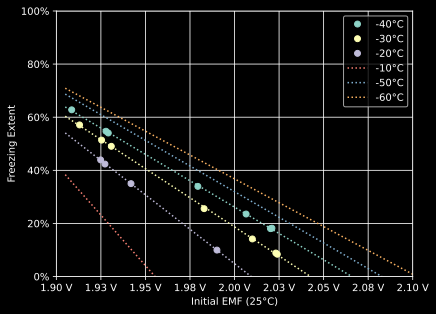

In [21]:
def freezing_extent(emf_lt: float, emf_vd: float) -> float:
    """Calculate the electrolyte mass fraction from the EMF value as per Stanton et.al 2025"""

    ZERO_OFFSET = 1.824
    MINIMUM_VALID_EMF = 1.95

    if emf_vd < MINIMUM_VALID_EMF:
        Warning("EMF value below valid range for calculation")
    return 1 - (emf_vd - ZERO_OFFSET) / (emf_lt - ZERO_OFFSET)


def mass_fraction_to_emf(mass_fraction: float) -> float:
    """Calculate the EMF value from the electrolyte mass fraction as per Stanton et.al 2025"""

    ZERO_OFFSET = 1.824
    GAIN = 0.784

    return ZERO_OFFSET + GAIN * mass_fraction


def plot_freezing_extent(frozen_emf_df) -> Figure:
    # Plot each isotherm of freezing extent vs the room temperature EMF
    fig, ax = plt.subplots()

    PROJECTION_MIN = 1.905

    for temperature in frozen_emf_df["Temperature"].unique():
        temp_df = frozen_emf_df[frozen_emf_df["Temperature"] == temperature]
        room_temp_emf = temp_df["VD_EMF"]
        f = [
            freezing_extent(emf_lt, emf_vd)
            for emf_lt, emf_vd in zip(temp_df["LT_EMF"], temp_df["VD_EMF"])
        ]

        ax.plot(
            room_temp_emf,
            f,
            marker="o",
            label=f"{temperature}°C",
            linestyle="",
        )

        if len(room_temp_emf) >= 2:
            coeffs = np.polyfit(
                room_temp_emf,
                f,
                deg=1,
            )
            poly = np.poly1d(coeffs)
            x_proj = 1.75
            y_proj = poly(x_proj)
            x_intercept = -coeffs[1] / coeffs[0]
            if x_intercept > room_temp_emf.iloc[-1]:
                ax.plot(
                    [PROJECTION_MIN, x_intercept],
                    [poly(PROJECTION_MIN), 0],
                    linestyle=":",
                    color=ax.get_lines()[-1].get_color(),
                )

            print(
                f"Temperature: {temperature}°C, Projection to x-intercept: {x_intercept:.3f} V, Weight Percent: {((x_intercept - 1.824) / 0.784)*100:.1f}%"
            )

    # Also plot projections for the -10, -50 and -60°C isotherms
    for temperature, mass_fraction_eq in [
        # Data Sourced from CRC Handbook Chem & Physics 61st Ed with linear interpolation
        (-10, 0.16762),
        # (-15, 0.20958),
        (-50, 0.32996),
        (-60, 0.35509),
    ]:

        x_intercept = mass_fraction_to_emf(mass_fraction_eq)
        ax.plot(
            [PROJECTION_MIN, x_intercept],
            [freezing_extent(x_intercept, PROJECTION_MIN), 0],
            linestyle=":",
            label=f"{temperature}°C",
        )
        print(
            f"Temperature: {temperature}°C, Projection to x-intercept: {x_intercept:.3f} V, Weight Percent: {mass_fraction_eq*100:.1f}%"
        )

    ax.set_xlabel("Initial EMF (25°C)")
    ax.set_ylabel("Freezing Extent")

    ax.legend()

    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{100*x:.0f}%"))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f} V"))
    ax.set_ylim(bottom=0, top=1)
    ax.set_xlim(left=PROJECTION_MIN - 0.005, right=2.1)
    ax.grid()

    return fig


freezing_extent_plot = plot_freezing_extent(frozen_emf_df)
freezing_extent_plot

## Latex Export



In [22]:
import os
import matplotlib
import importlib

colorBlindColors = [
    "#377eb8",
    "#ff7f00",
    "#4daf4a",
    "#f781bf",
    "#a65628",
    "#984ea3",
    "#999999",
    "#e41a1c",
    "#dede00",
    "#000000",
]

importlib.reload(matplotlib)

plt.rcParams.update(matplotlib.rcParamsDefault)

matplotlib.use("pgf")

color_blind_cycle = cycler(color=colorBlindColors)

plt.rcParams.update(
    {
        "pgf.texsystem": "pdflatex",
        "text.usetex": True,
        "pgf.rcfonts": False,
        # ensure color is the primary cycle and linestyle alternates
        "axes.prop_cycle": color_blind_cycle,
    }
)

tikzSaveDir = "../Plots/Latex"
os.makedirs(tikzSaveDir, exist_ok=True)

In [23]:
emf_change_plot_pgf = plot_emf_change(emf_vd_df, emf_lt_df)
emf_change_plot_pgf.savefig(
    path.join(tikzSaveDir, "EMF-Change.pgf"),
)

os.rename(
    path.join(tikzSaveDir, "EMF-Change.pgf"),
    path.join(tikzSaveDir, "EMF-Change.tex"),
)

In [24]:
freezing_extent_plot_pgf = plot_freezing_extent(frozen_emf_df)

freezing_extent_plot_pgf.axes[0].set_ylabel(r"Freezing Extent, $F$")

freezing_extent_plot_pgf.savefig(
    path.join(tikzSaveDir, "Freezing-Extent.pgf"),
)

os.rename(
    path.join(tikzSaveDir, "Freezing-Extent.pgf"),
    path.join(tikzSaveDir, "Freezing-Extent.tex"),
)

Temperature: -40°C, Projection to x-intercept: 2.066 V, Weight Percent: 30.8%
Temperature: -30°C, Projection to x-intercept: 2.043 V, Weight Percent: 27.9%
Temperature: -20°C, Projection to x-intercept: 2.009 V, Weight Percent: 23.6%
Temperature: -10°C, Projection to x-intercept: 1.955 V, Weight Percent: 16.8%
Temperature: -50°C, Projection to x-intercept: 2.083 V, Weight Percent: 33.0%
Temperature: -60°C, Projection to x-intercept: 2.102 V, Weight Percent: 35.5%
